# 02 — Búsqueda Tabú (Tabu Search)
**Metaheurísticas — Notebook 2 de 5**

La Búsqueda Tabú (Fred **Glover, 1986**) es una metaheurística de **trayectoria**
(una sola solución). Es búsqueda local con **memoria**: siempre se mueve al mejor
vecino — aunque empeore — y una lista "tabú" prohíbe deshacer movimientos recientes.

## ¿Qué aprenderás?
1. Qué es búsqueda local y por qué se queda atrapada en óptimos locales.
2. La **lista tabú**, el **tenure** y el **criterio de aspiración**.
3. Intensificación vs. **diversificación**.
4. Implementación para:
   - **Ejemplo 1 — Coloración de Grafos** (20 nodos).
   - **Ejemplo 2 — Corte Máximo (Max-Cut)**.
5. Efecto del tenure en la convergencia.


## 1. Búsqueda local y sus limitaciones

Búsqueda local (hill-climbing) se mueve siempre al mejor vecino y para cuando
ninguno mejora — queda atrapada en **óptimos locales**. Búsqueda Tabú los supera:

1. **Acepta movimientos que empeoran** (siempre avanza).
2. **Prohíbe deshacer** movimientos recientes con la lista tabú.

```
funcion TabuSearch(s0, tenure, max_iter):
    s <- s0;  s_mejor <- s0;  TabuList <- {}
    para it en 1..max_iter:
        candidatos <- { (attr, s') in N(s) : NO tabu(attr) O aspira(s') }
        (attr*, s*) <- argmin costo(s')  sobre candidatos
        s <- s*
        tabu[attr*] <- it + tenure      # prohibir por tenure iteraciones
        si costo(s) < costo(s_mejor): s_mejor <- s
    retornar s_mejor
```

## 2. Componentes clave

### Lista tabú y tenure
Guarda **atributos** de movimientos recientes (NO soluciones completas — sería costoso).
El **tenure** $\tau$ controla cuántas iteraciones dura la prohibición:
- $\tau$ pequeño → **intensificación**: explota localmente, puede ciclar.
- $\tau$ grande → **diversificación**: fuerza nuevas regiones, converge lento.
- Regla empírica: $\tau \approx \sqrt{n}$ o entre 5–20.

### Criterio de aspiración
Excepción a la prohibición: si un movimiento tabú produce una solución **mejor
que el incumbente global**, se permite de todas formas. Evita bloquear descubrimientos excelentes.

### Intensificación vs. Diversificación
- **Intensificación:** memoria de largo plazo para favorecer atributos de soluciones
  buenas; reiniciar desde el incumbente.
- **Diversificación:** penalizar atributos muy usados; perturbaciones grandes;
  tenure largo.


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("common.py")))
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import common

G = common.crear_grafo(n=20, prob=0.35, seed=42)
pos = common.posiciones_grafo(G, seed=42)
n = G.number_of_nodes()
print(f"Grafo: {n} nodos, {G.number_of_edges()} aristas, grado medio: {2*G.number_of_edges()/n:.2f}")

s0 = common.coloracion_greedy(G, seed=7)
print(f"\nColoracion greedy inicial:")
print(f"  Colores: {common.num_colores(s0)}, Conflictos: {common.calcular_conflictos(s0, G)}")
print(f"  Costo:   {common.costo(s0, G)}")


Grafo: 20 nodos, 76 aristas, grado medio: 7.60

Coloracion greedy inicial:
  Colores: 6, Conflictos: 0
  Costo:   6


In [2]:
def busqueda_tabu(G, s0, tenure=8, max_iter=300, seed=0):
    """
    Busqueda Tabu para Coloracion de Grafos.

    Movimiento: cambiar el color de un nodo.
    Atributo tabu: (nodo, color_anterior) - prohibir volver al color previo del mismo nodo.
    Vecindario eficiente: solo explora nodos con conflictos activos.
    """
    rng = np.random.default_rng(seed)
    adj = {v: list(G.neighbors(v)) for v in range(n)}

    s_actual = list(s0)
    s_mejor = list(s0)
    costo_mejor = common.costo(s_mejor, G)
    lista_tabu = {}   # (nodo, color_anterior) -> iteracion en que expira
    historia = [costo_mejor]

    for it in range(max_iter):
        candidato_sol = None
        candidato_attr = None
        candidato_costo = np.inf

        nodos_conf = [v for v in range(n)
                      if any(s_actual[v] == s_actual[u] for u in adj[v])]
        nodos_a_ver = nodos_conf if nodos_conf else list(range(n))

        k_max = max(s_actual) + 2   # colores disponibles + 1 nuevo

        for v in nodos_a_ver:
            for nuevo_c in range(k_max):
                if nuevo_c == s_actual[v]:
                    continue
                attr = (v, s_actual[v])
                nueva = list(s_actual)
                nueva[v] = nuevo_c
                c = common.costo(nueva, G)

                es_tabu = lista_tabu.get(attr, -1) > it
                aspira  = c < costo_mejor   # criterio de aspiracion

                if (not es_tabu or aspira) and c < candidato_costo:
                    candidato_sol  = nueva
                    candidato_attr = attr
                    candidato_costo = c

        if candidato_sol is None:
            break

        s_actual = candidato_sol
        lista_tabu[candidato_attr] = it + tenure

        if candidato_costo < costo_mejor:
            s_mejor = list(s_actual)
            costo_mejor = candidato_costo
        historia.append(costo_mejor)

    return s_mejor, costo_mejor, historia

s_ts, costo_ts, hist_ts = busqueda_tabu(G, s0, tenure=8, max_iter=300)
print(f"Busqueda Tabu resultado:")
print(f"  Colores: {common.num_colores(s_ts)}, Conflictos: {common.calcular_conflictos(s_ts, G)}")
print(f"  Valida:  {common.coloracion_valida(s_ts, G)}")
print(f"\nMejora: {common.num_colores(s0)} -> {common.num_colores(s_ts)} colores")


Busqueda Tabu resultado:
  Colores: 6, Conflictos: 0
  Valida:  True

Mejora: 6 -> 6 colores


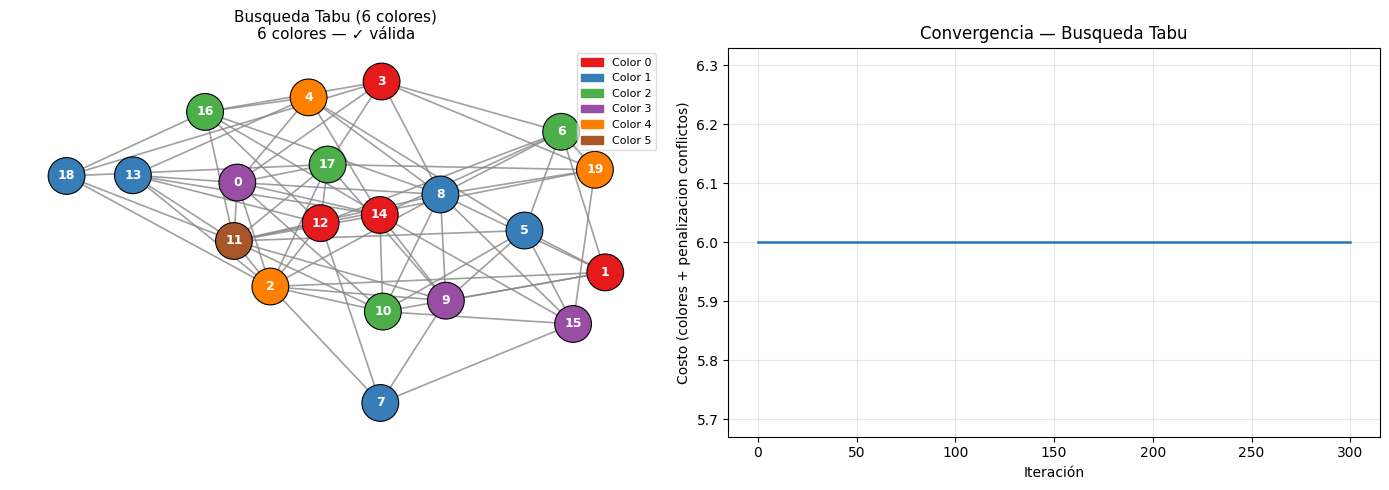

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
common.plot_grafo(G, s_ts,
    f"Busqueda Tabu ({common.num_colores(s_ts)} colores)", ax=axes[0], pos=pos)
common.plot_convergencia(hist_ts, "Convergencia — Busqueda Tabu",
    "Costo (colores + penalizacion conflictos)", ax=axes[1])
plt.tight_layout(); plt.show()


### Efecto del tenure en la convergencia

El tenure es el parámetro más crítico. Valores extremos degradan la calidad.


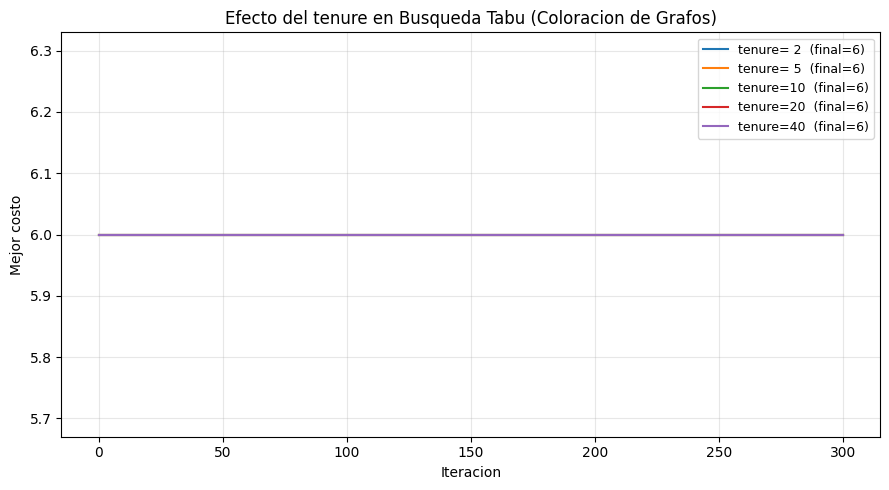

Tenure muy corto -> cicla; tenure muy largo -> diversifica sin explotar.


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colores_linea = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple"]
for i, tenure in enumerate([2, 5, 10, 20, 40]):
    _, cf, h = busqueda_tabu(G, s0, tenure=tenure, max_iter=300)
    ax.plot(h, label=f"tenure={tenure:2d}  (final={cf})", color=colores_linea[i], lw=1.5)
ax.set_title("Efecto del tenure en Busqueda Tabu (Coloracion de Grafos)")
ax.set_xlabel("Iteracion"); ax.set_ylabel("Mejor costo")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("Tenure muy corto -> cicla; tenure muy largo -> diversifica sin explotar.")


## Ejemplo 2 — Corte Máximo (Max-Cut)

Dado $G=(V,E)$, particionar los nodos en $S$ y $\bar{S}$ maximizando el número
de **aristas que cruzan la partición**. NP-difícil. Aplicaciones: diseño VLSI,
modelo de Ising, clustering espectral.

**Movimiento:** flip de un nodo ($S \leftrightarrow \bar{S}$).
**Atributo tabú:** el nodo que acaba de cambiar de partición.


In [5]:
def corte(part, G):
    return sum(1 for u, v in G.edges() if part[u] != part[v])

def ts_max_cut(G, tenure=7, max_iter=500, seed=1):
    """
    Busqueda Tabu para Max-Cut.
    part[v] en {0,1}: particion del nodo v.
    Movimiento: flip(v) cambia la particion de v.
    Objetivo: maximizar el corte -> minimizamos su negativo.
    """
    rng = np.random.default_rng(seed)
    n_local = G.number_of_nodes()
    part = list(rng.integers(0, 2, size=n_local))
    mejor_p = list(part)
    mejor_c = corte(part, G)
    lista_tabu = {}
    historia = [mejor_c]

    for it in range(max_iter):
        cand_v = None; cand_c = -1
        for v in range(n_local):
            nueva = list(part); nueva[v] ^= 1
            c = corte(nueva, G)
            es_tabu = lista_tabu.get(v, -1) > it
            aspira  = c > mejor_c
            if (not es_tabu or aspira) and c > cand_c:
                cand_v = v; cand_c = c
        if cand_v is None:
            break
        part[cand_v] ^= 1
        lista_tabu[cand_v] = it + tenure
        if cand_c > mejor_c:
            mejor_p = list(part); mejor_c = cand_c
        historia.append(mejor_c)

    return mejor_p, mejor_c, historia

part_ts, corte_ts, hist_mc = ts_max_cut(G, tenure=7, max_iter=500)
print(f"Max-Cut (Tabu): {corte_ts} de {G.number_of_edges()} aristas cortadas")
print(f"Porcentaje: {100*corte_ts/G.number_of_edges():.1f}%")
rng_ref = np.random.default_rng(1)
p_rand = list(rng_ref.integers(0, 2, size=n))
print(f"Referencia aleatoria: {corte(p_rand, G)} aristas")


Max-Cut (Tabu): 53 de 76 aristas cortadas


Porcentaje: 69.7%
Referencia aleatoria: 44 aristas


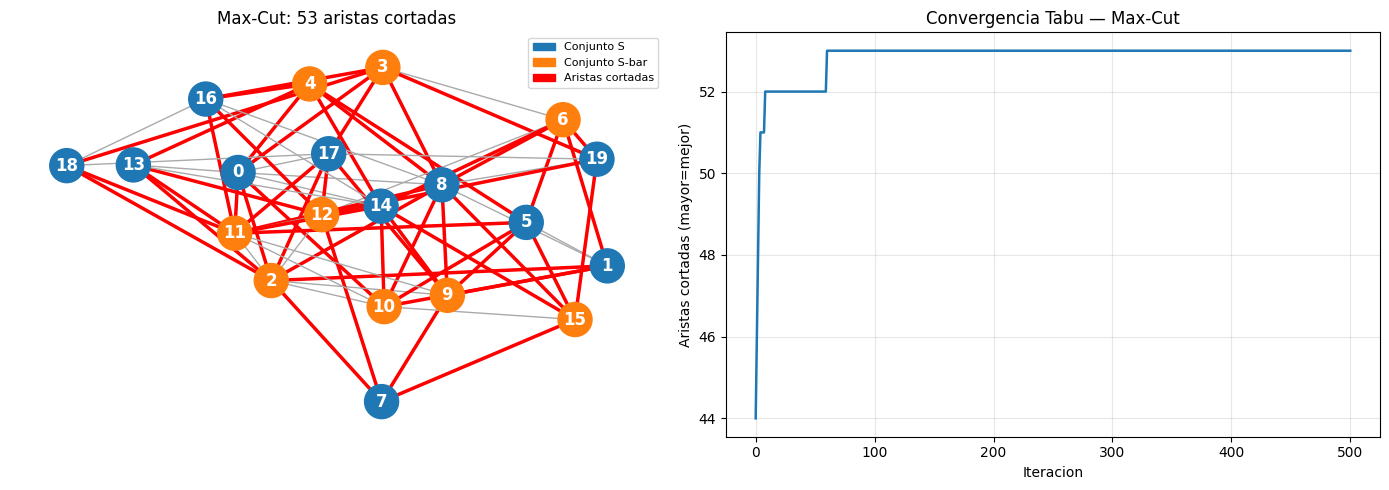

In [6]:
import matplotlib.patches as mpatches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nc = ["tab:blue" if part_ts[v]==0 else "tab:orange" for v in range(n)]
ec = ["red" if part_ts[u]!=part_ts[v] else "#aaaaaa" for u,v in G.edges()]
ew = [2.5 if part_ts[u]!=part_ts[v] else 1.0 for u,v in G.edges()]
nx.draw(G, pos, ax=axes[0], node_color=nc, with_labels=True, node_size=600,
        font_color="white", font_weight="bold", edge_color=ec, width=ew)
ley=[mpatches.Patch(color="tab:blue",label="Conjunto S"),
     mpatches.Patch(color="tab:orange",label="Conjunto S-bar"),
     mpatches.Patch(color="red",label="Aristas cortadas")]
axes[0].legend(handles=ley, loc="upper right", fontsize=8)
axes[0].set_title(f"Max-Cut: {corte_ts} aristas cortadas")

axes[1].plot(hist_mc, color="tab:blue", lw=1.8)
axes[1].set_title("Convergencia Tabu — Max-Cut")
axes[1].set_xlabel("Iteracion"); axes[1].set_ylabel("Aristas cortadas (mayor=mejor)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Parámetros, complejidad y preguntas frecuentes

**Complejidad por iteración:** $O(|N(s)|)$. Para coloración: $O(n \cdot k)$.
Con evaluación incremental (solo delta de nodos afectados) puede reducirse a $O(k)$.

**¿Qué se guarda en la lista tabú: solución o movimiento?**
El **movimiento** (atributo compacto, ej. un par de enteros). Guardar soluciones
completas sería $O(n)$ por entrada y costoso de comparar.

**¿Por qué aceptar movimientos que empeoran?**
Para escapar óptimos locales. La búsqueda local pura no puede "subir la colina"
para luego bajar a un valle más profundo. Tabú sí puede, y el tenure evita ciclos.

**¿Cuál es la diferencia entre Tabú e intensificación/diversificación?**
La lista tabú (corto plazo) es el mecanismo básico. La **memoria de largo plazo**
(frecuencia de movimientos) permite intensificación/diversificación explícita:
penalizar movimientos frecuentes (diversificar) o favorecer atributos de buenas
soluciones (intensificar).

**¿Cuándo usar Tabú vs. SA o GA?**
- **Tabú:** vecindario bien estructurado y evaluable eficientemente; scheduling, routing.
- **SA:** vecindario sencillo de muestrear; implementación mínima.
- **GA:** cuando el crossover de soluciones tiene sentido semántico.

## Ejercicios
1. Implementa **evaluación incremental** para Max-Cut (solo delta de aristas del nodo flipado).
2. Agrega **frecuencia de movimientos** como penalización a largo plazo.
3. Compara tenure fijo vs. tenure aleatorio en $[t_{\min}, t_{\max}]$.
4. Para coloración, prueba intercambiar los colores de dos nodos adyacentes en conflicto.

## Referencias
- Glover (1986), *Future paths for integer programming and links to AI*.
- Glover & Laguna, *Tabu Search* (1997).
- Hertz & de Werra (1987), *Using tabu search techniques for graph coloring*.
